## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with analyzing the data, developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Please read the instructions carefully before starting the project.**

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

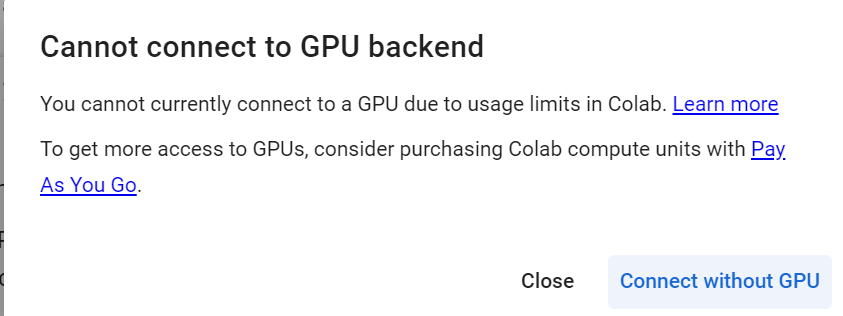

## **Installing and Importing Necessary Libraries**

In [ ]:
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.1.85 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 289.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 264.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 228.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 289.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine 

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
#!pip install -U sentence-transformers gensim transformers tqdm -q
!pip install -U sentence-transformers==4.0.2 gensim==4.3.3 transformers==4.50.3 tqdm==4.67.1 scikit-learn==1.6.1 pandas==2.2.2 numpy==1.26.4 matplotlib==3.10.0 seaborn==0.13.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.6/340.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## **Loading the dataset**

In [ ]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
import os  # Import the os module

file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert", "-q"]) # installing nbconvert, if not already installed
html_filename = file0[:-5] + "html"  # Construct the HTML filename
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html", "--output", html_filename]) # specifying output filename

# Check if the file exists before downloading
if os.path.exists(html_filename):
  files.download(html_filename)
else:
  print(f"Error: The file '{html_filename}' was not created during conversion.")

Saving Lokesh_NLP_Project_Full_Code_New.ipynb to Lokesh_NLP_Project_Full_Code_New.ipynb
Error: The file 'Lokesh_NLP_Project_Full_Code_New.html' was not created during conversion.


In [ ]:
# To manipulate and analyze data
import pandas as pd
import numpy as np

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# To used time-related functions
import time

# To parse JSON data
import json

# To build, tune, and evaluate ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# To load/create word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# To implement progress bar related functionalities
from tqdm import tqdm
tqdm.pandas()

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# # uncomment and run the following code if Google Colab is being used and the dataset is in Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Code to read the CSV file.
stock_news = pd.read_csv("/content/drive/MyDrive/NLP/project/stock_news.csv")

In [ ]:
#Creating a copy of the dataset
stock = stock_news.copy()

## **Data Overview**

Displaying the first  and Last few rows of the dataset

In [ ]:
#check the first 5 rows of the data
stock.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


In [ ]:
#check the Last 5 rows of the data
stock.tail()

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influenc...",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks u...",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,This article reports that the S&P 500 reached...,50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,The Federal Reserve is anticipated to keep in...,50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung E...",50.764999,50.849998,49.7775,48.70879,186139600,0


In [ ]:
#check the shape of the data
stock.shape

(349, 8)

**Observation:**

There are 349 records and 8 columns.

In [ ]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [ ]:
#  check the data types
stock.dtypes

,0
Date,object
News,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Label,int64


**Observation:**

There are 2 object datatypes.

There are 4 float64 datatypes.

There are 2 int64 datatypes.

Date column is defined as Object , Need to convert date column from object to date


In [ ]:
# to convert the 'Date' column in the 'stock' DataFrame to datetime format.
stock['Date'] = pd.to_datetime(stock['Date'])

In [ ]:
stock.dtypes

,0
Date,datetime64[ns]
News,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Label,int64


**Checking the statistical summary**


In [ ]:
# to check the statistical summary
stock.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


In [ ]:
# to check the statistical summary
stock.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,349,2019-02-16 16:05:30.085959936,2019-01-02 00:00:00,2019-01-14 00:00:00,2019-02-05 00:00:00,2019-03-22 00:00:00,2019-04-30 00:00:00,NaN
Open,349.0,46.229233,37.567501,41.740002,45.974998,50.7075,66.817497,6.442817
High,349.0,46.700458,37.817501,42.244999,46.025002,50.849998,67.0625,6.507321
Low,349.0,45.745394,37.305,41.482498,45.639999,49.7775,65.862503,6.391976
Close,349.0,44.926317,36.254131,40.246914,44.596924,49.11079,64.805229,6.398338
Volume,349.0,128948236.103152,45448000.0,103272000.0,115627200.0,151125200.0,244439200.0,43170314.918964
Label,349.0,-0.054441,-1.0,-1.0,0.0,0.0,1.0,0.715119


**Checking the duplicate values**

In [ ]:
# code to check the duplicate values
stock.duplicated().sum()

0

**Observation:**

There are no duplicate Values found from the data set

**Checking for missing values**

In [ ]:
# check for missing values in the data
stock.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


**Observation:**

There are no missing values found from the data set.

In [ ]:
#Column List
stock.columns.tolist()

['Date', 'News', 'Open', 'High', 'Low', 'Close', 'Volume', 'Label']

## **Exploratory Data Analysis**

### Univariate Analysis

* Distribution of individual variables
* Compute and check the distribution of the length of news content

**Observations on Label**

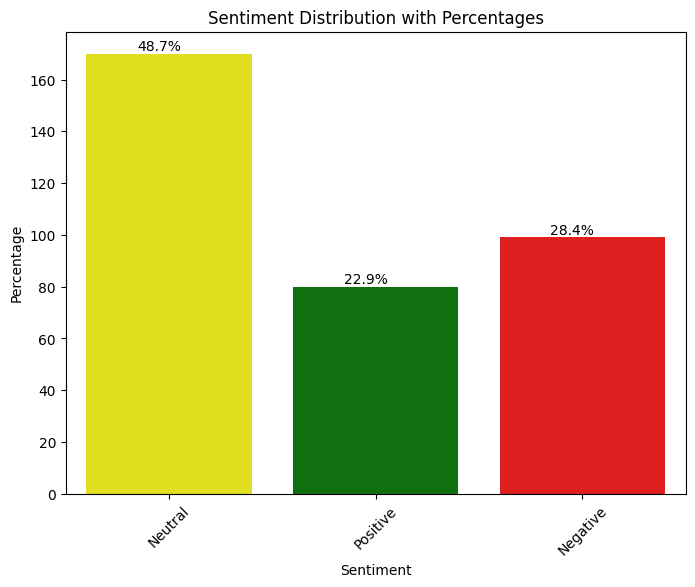

In [ ]:
# Define the dataframes for each sentiment
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
stock = stock.copy()
stock = pd.DataFrame(stock)

# Create a mapping for the sentiment labels
sentiment_mapping = {0: 'Neutral', 1: 'Positive', -1: 'Negative'}

# Map the sentiment labels to the DataFrame
stock['Label'] = stock['Label'].map(sentiment_mapping)

# Define a custom color palette
custom_palette = {'Neutral': 'yellow', 'Positive': 'green', 'Negative': 'red'}

# Create the countplot with custom labels and colors
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=stock, x="Label", order=['Neutral', 'Positive', 'Negative'], palette=custom_palette)

# Add percentage values to the countplot
total = len(stock)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

# Rotate the x-axis labels by 45 degrees
plt.xticks(rotation=45)

# Set plot labels and title
ax.set_xlabel('Sentiment')
ax.set_ylabel('Percentage')
ax.set_title('Sentiment Distribution with Percentages')

# Show the plot
plt.show()


**Observation:**

There are different clasified reviews are found from tha data set, Neutral reviews are Higher than other sentiments .

49% Neutral (0)

23% Positive (1)

28% Negative (-1)


**Density Plot of Price (Open,High,Low,Close)**

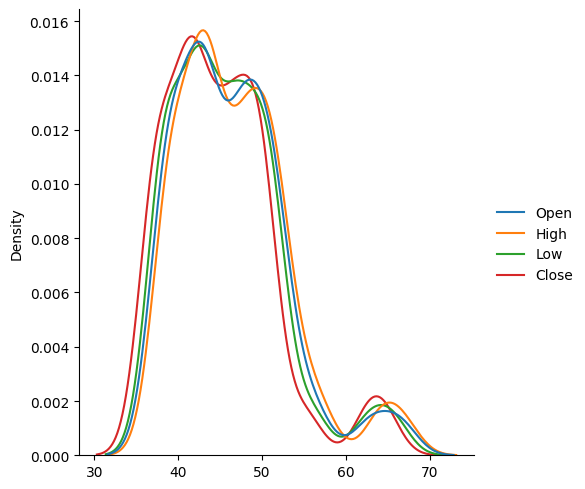

In [ ]:
# Corrected the column selection to access individual columns
sns.displot(data=stock[["Open","High","Low","Close"]], kind="kde")

In [ ]:
stock['High'].mean()

46.70045808595988

In [ ]:
stock['High'].median()

46.025002

**Observations:**


*   Density is very high for the highest stock price reached during the day at mean/median value of High Stock high price.
*   Density is low at less price and very high proce for all the scenarios of stock price reached during the day.


**Observations on Volume**

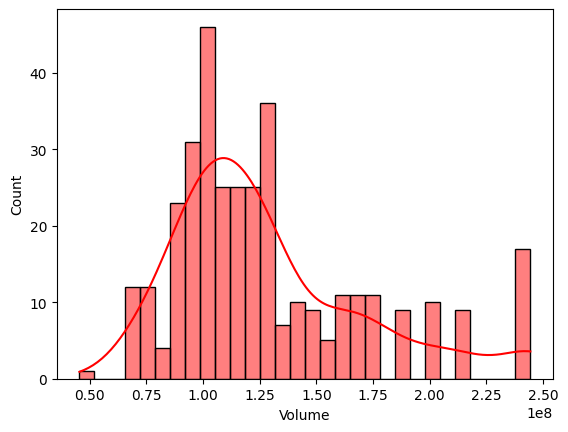

In [ ]:
#  code to plot a histogram of Volume
sns.histplot(stock, x='Volume', bins=30, kde=True, color='red');

In [ ]:
stock['Volume'].mean()

128948236.10315186

In [ ]:
stock['Volume'].median()

115627200.0

In [ ]:
stock['Volume'].min()

45448000

In [ ]:
stock['Volume'].max()

244439200

**Observation:**

*   Minimum volume of shares traded during the day:45448000, Volume Count is very minimal for Minimum Trading Volume.
*   As per the above plot Volume count is very high at median volume value:115627200.0 and Volume count is high at mean value:128948236.10315186



**Observations on News length**

In [ ]:
#Calculating the total number of words present in the news content.
stock['news_len'] = stock['News'].apply(lambda x: len(x.split(' ')))
stock[['News', 'news_len']].describe().T   # Accessing the 'News' column directly from the 'stock' DataFrame

,count,mean,std,min,25%,50%,75%,max
news_len,349.0,49.312321,5.72777,19.0,46.0,50.0,53.0,61.0


**Observation:**

The dataset contains 349 news articles.

The average length of the news articles is approximately 49.31 words.

The lengths of the news articles vary, with a standard deviation of approximately 5.73 words.

The shortest news article contains 19 words, while the longest contains 61 words.

The median length of the news articles is 50 words, indicating that half of the articles have 50 words or fewer.

The 25th and 75th percentiles are 46 and 53 words, respectively, indicating the range within which the middle 50% of the news article lengths fall.

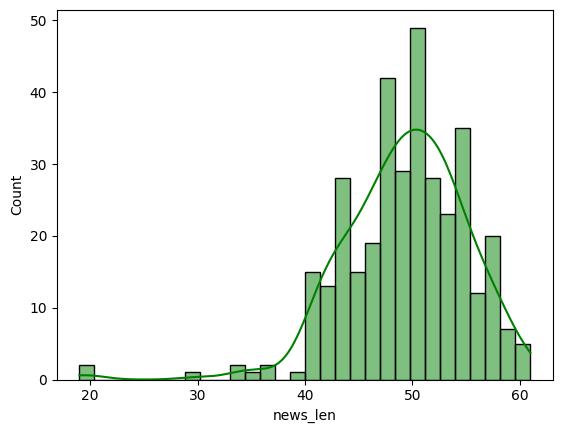

In [ ]:
sns.histplot(data=stock,x="news_len",kde=True,bins=30,color='green'); #Complete the code to plot a histogram of news_len column

**Observation:**

Length of news articles is left skewed.

### Bivariate Analysis

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

**Note**: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

**Correlation**

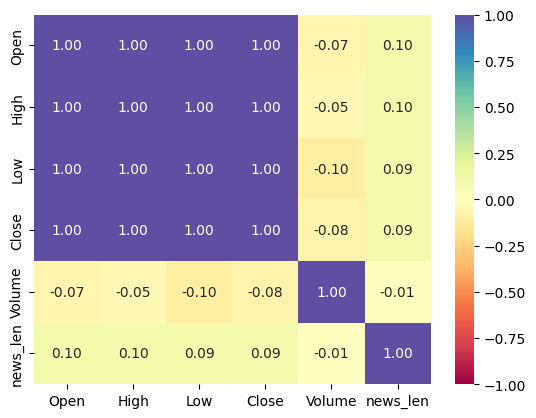

In [ ]:
sns.heatmap(
    stock[['Open', 'High', 'Low', 'Close', 'Volume', 'news_len']].corr(), # Selecting numeric features and calculating the correlation matrix
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="Spectral"
);    #Complete the code to plot the correlation matrix for numeric columns only.

**Observations:**

All the Variables are Possitively correlated

**Label vs Price (Open, High, Low, Close)**

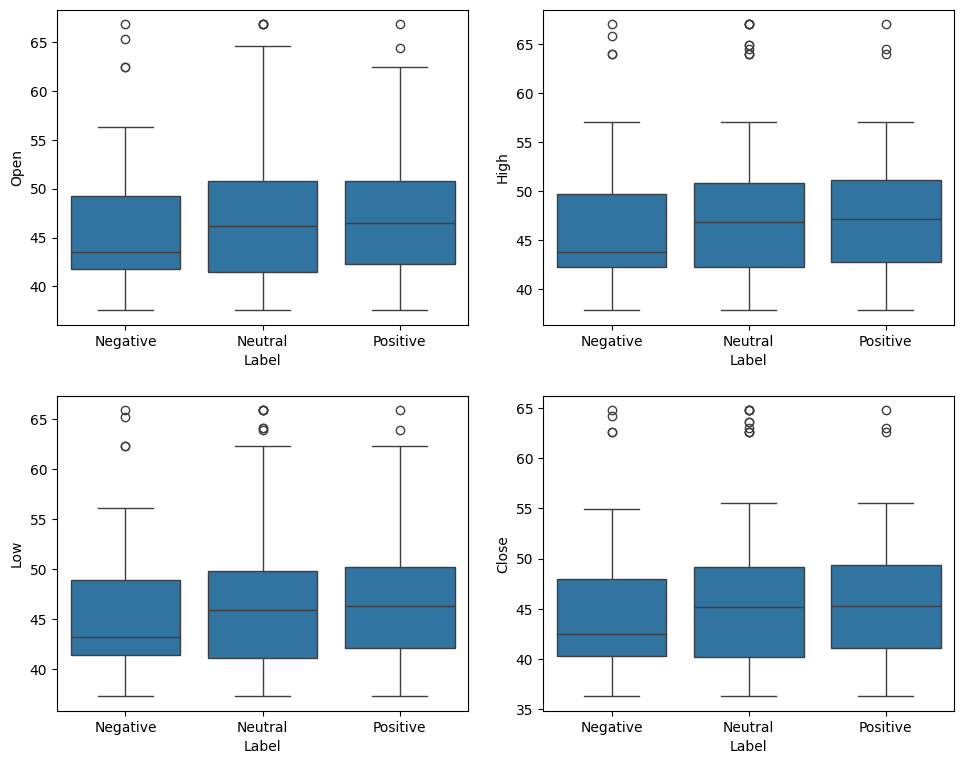

In [ ]:
plt.figure(figsize=(10, 8))

for i, variable in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=stock, x="Label", y=variable)
    plt.tight_layout(pad=2)

plt.show()

**Label vs Volume**

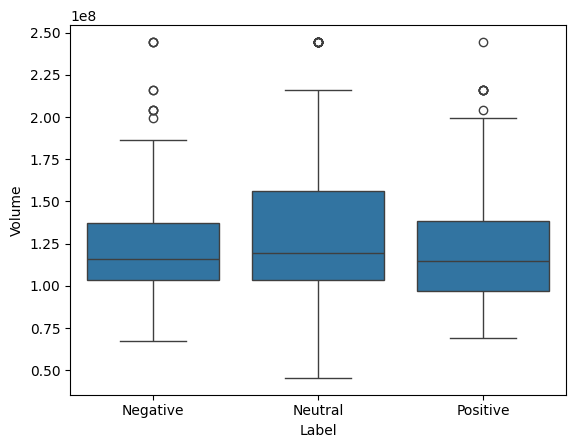

In [ ]:
# plot a boxplot of Label vs Volume
sns.boxplot(
    data=stock, x="Label", y="Volume"
);

**Date vs Price (Open, High, Low, Close)**

In [ ]:
stock_daily = stock.groupby('Date').agg(
    {
        'Open': 'mean',
        'High': 'mean',
        'Low': 'mean',
        'Close': 'mean',
        'Volume': 'mean',
    }
).reset_index()  # Group the 'stocks' DataFrame by the 'Date' column

stock_daily.set_index('Date', inplace=True)
stock_daily.head()

,Open,High,Low,Close,Volume
Date,,,,,
2019-01-02,41.740002,42.244999,41.482498,40.246914,130672400.0
2019-01-03,43.570000,43.787498,43.222500,42.470604,103544800.0
2019-01-04,47.910000,47.919998,47.095001,46.419842,111448000.0
2019-01-07,50.792500,51.122501,50.162498,49.110790,109012000.0
2019-01-08,53.474998,54.507500,51.685001,50.787209,216071600.0


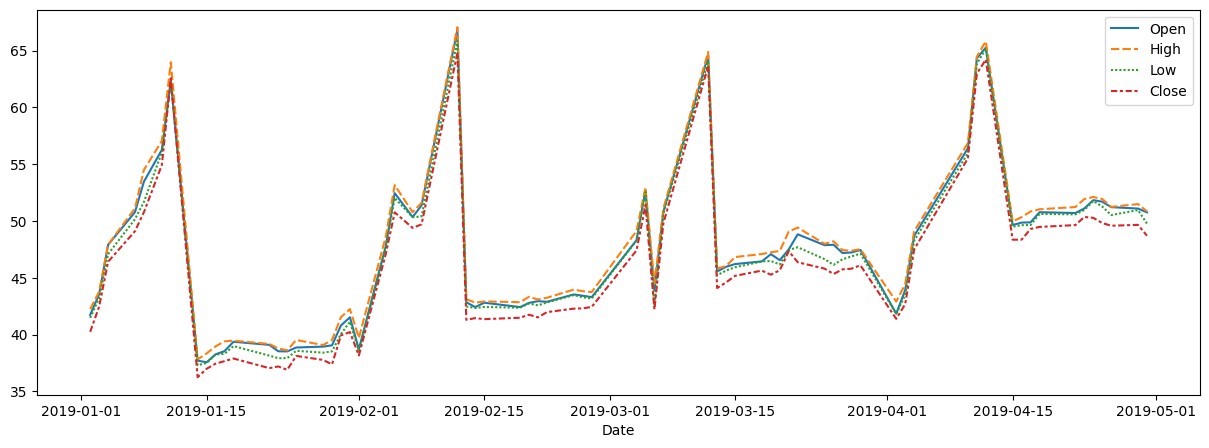

In [ ]:
plt.figure(figsize=(15,5))
sns.lineplot(stock_daily.drop('Volume', axis=1)); #Complete the code to plot a lineplot of all the variables except Volume

**Observations:**


**Volume vs Close Price**

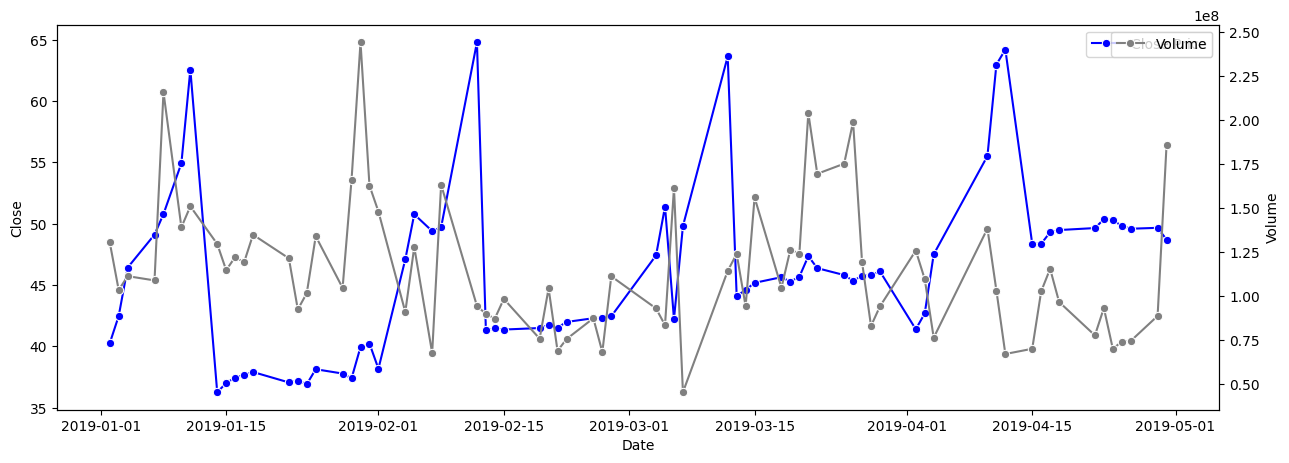

In [ ]:
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(15,5))

# Lineplot on primary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Close', ax=ax1, color='blue', marker='o', label='Close Price')

# Create a secondary y-axis
ax2 = ax1.twinx()

# Lineplot on secondary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Volume', ax=ax2, color='gray', marker='o', label='Volume')

ax1.legend(bbox_to_anchor=(1,1));

**Observations:**

## **Data Preprocessing**

In [ ]:
# print the statistical summary of the 'Date' column
stock["Date"].describe()

,Date
count,349
mean,2019-02-16 16:05:30.085959936
min,2019-01-02 00:00:00
25%,2019-01-14 00:00:00
50%,2019-02-05 00:00:00
75%,2019-03-22 00:00:00
max,2019-04-30 00:00:00


In [ ]:
# Extract relevant date components for summarization
stock['Year'] = stock['Date'].dt.year
stock['Month'] = stock['Date'].dt.month
stock['Day'] = stock['Date'].dt.day

# Print the statistical summary of the 'Date' column components
print("Year Summary:")
print(stock['Year'].describe())
print("\nMonth Summary:")
print(stock['Month'].describe())
print("\nDay Summary:")
print(stock['Day'].describe())

Year Summary:
count     349.0
mean     2019.0
std         0.0
min      2019.0
25%      2019.0
50%      2019.0
75%      2019.0
max      2019.0
Name: Year, dtype: float64

Month Summary:
count    349.000000
mean       2.077364
std        1.177997
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: Month, dtype: float64

Day Summary:
count    349.000000
mean      15.389685
std        9.351840
min        1.000000
25%        6.000000
50%       15.000000
75%       24.000000
max       31.000000
Name: Day, dtype: float64


**Observations:**

All entries in the dataset are from the year 2019.

The entries are concentrated in the first four months of the year, with a significant number of entries from January and February.

The entries are spread throughout the days of the month, with a relatively even distribution.

**Train-test-validation Split**

In [ ]:
#code to select all rows where the 'Date' is before '2019-04-01'
X_train = stock[(stock['Date'] < '2019-04-01')].reset_index()
# code to select all rows where the 'Date' is from '2019-04-01 to '2019-04-16' (excluded)
X_val = stock[(stock['Date'] >= '2019-04-01') & (stock['Date'] < '2019-04-16')].reset_index()
 # the code to select all rows where the 'Date' is from '2019-04-16' till the end.
X_test = stock[stock['Date'] >= '2019-04-16'].reset_index()

In [ ]:
# Complete the code to pick the 'Label' column as the target variable
y_train = X_train["Label"].copy()
y_val = X_val["Label"].copy()
y_test = X_test["Label"].copy()

In [ ]:
#Complete the code to print the shape of X_train,X_val,X_test,y_train,y_val and y_test
print("Train data shape",X_train.shape)
print("Validation data shape",X_val.shape)
print("Test data shape ",X_test.shape)

print("Train label shape",y_train.shape)
print("Validation label shape",y_val.shape)
print("Test label shape ",y_test.shape)

Train data shape (286, 13)
Validation data shape (21, 13)
Test data shape  (42, 13)
Train label shape (286,)
Validation label shape (21,)
Test label shape  (42,)


In [ ]:
# First 5 rows of Traiing data
X_train.head()

,index,Date,News,Open,High,Low,Close,Volume,Label,news_len,Year,Month,Day
0,0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,Negative,46,2019,1,2
1,1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,Negative,51,2019,1,2
2,2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,Negative,49,2019,1,2
3,3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,Negative,51,2019,1,2
4,4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,Negative,50,2019,1,2


In [ ]:
# First 5 rows of Validation data
X_val.head()

,index,Date,News,Open,High,Low,Close,Volume,Label,news_len,Year,Month,Day
0,286,2019-04-02,"Apple and other consumer brands, including LV...",41.852501,42.915001,41.8200,41.390125,125982000,Neutral,45,2019,4,2
1,287,2019-04-02,Swatch Group successfully defended its use of...,41.852501,42.915001,41.8200,41.390125,125982000,Neutral,47,2019,4,2
2,288,2019-04-02,"In premarket trade Tuesday, Apple's NASDAQ AA...",41.852501,42.915001,41.8200,41.390125,125982000,Neutral,35,2019,4,2
3,289,2019-04-02,"In US markets, futures for the Dow, S&P 500, ...",41.852501,42.915001,41.8200,41.390125,125982000,Negative,47,2019,4,2
4,290,2019-04-03,"Japan Display, a key Apple supplier, is set t...",43.922501,44.437500,43.4925,42.684212,109744800,Positive,56,2019,4,3


In [ ]:
# First 5 rows of Test data
X_test.head()

,index,Date,News,Open,High,Low,Close,Volume,Label,news_len,Year,Month,Day
0,307,2019-04-16,"In a complex trial in San Diego, Apple accuse...",49.865002,50.342499,49.639999,48.364113,102785600,Neutral,54,2019,4,16
1,308,2019-04-17,"Taiwan business tycoon Terry Gou, chairman of...",49.884998,50.845001,49.652500,49.305897,115627200,Neutral,44,2019,4,17
2,309,2019-04-17,"Chinese video-sharing app TikTok, owned by By...",49.884998,50.845001,49.652500,49.305897,115627200,Neutral,52,2019,4,17
3,310,2019-04-17,"TomTom, a Dutch navigation and digital maps f...",49.884998,50.845001,49.652500,49.305897,115627200,Positive,48,2019,4,17
4,311,2019-04-17,"In a volatile trading session, the S&P 500 wa...",49.884998,50.845001,49.652500,49.305897,115627200,Positive,49,2019,4,17


In [ ]:
y_train.head()

,Label
0,Negative
1,Negative
2,Negative
3,Negative
4,Negative


In [ ]:
y_val.head()

,Label
0,Neutral
1,Neutral
2,Neutral
3,Negative
4,Positive


In [ ]:

y_test.head()

,Label
0,Neutral
1,Neutral
2,Neutral
3,Positive
4,Positive


## **Word Embeddings**

In [ ]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in stock['News'].values]

In [ ]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 4682


**Let's check out a few word embeddings obtained using the model.**

In [ ]:
# Checking the word embedding of a random word
word = "stock"
model_W2V.wv[word]

array([ 3.17075127e-03,  4.39528748e-02,  5.20399539e-03,  2.35255193e-02,
       -3.37727787e-03, -5.03616035e-02,  3.62131856e-02,  8.51981118e-02,
        9.77917388e-03, -1.54129118e-02,  1.13858245e-02, -2.18799058e-02,
        1.58083613e-03,  1.14338985e-02, -3.02003734e-02, -2.50892751e-02,
        2.04946175e-02, -1.35671366e-02, -1.81066128e-03, -1.33315399e-02,
       -2.71194559e-02,  1.63638487e-03,  3.73893268e-02,  7.74854794e-03,
        1.43390661e-02,  6.10655732e-03, -4.27048728e-02,  6.59106951e-03,
       -1.75017007e-02, -3.46826166e-02,  1.38892513e-02, -2.13511046e-02,
        3.41462856e-03, -3.05916672e-03, -4.10708040e-03,  1.73748042e-02,
        1.70111321e-02, -3.83425839e-02,  2.36877380e-03, -9.86508187e-03,
       -1.53577561e-02, -2.12182873e-03, -1.33712380e-03, -2.64293533e-02,
        1.63260475e-02,  4.08548191e-02, -1.37681986e-04,  1.02436142e-02,
       -1.49007654e-03,  2.73992680e-02,  2.10906416e-02,  5.61619550e-03,
       -1.73362959e-02,  

In [ ]:
# Checking the word embedding of a random word
word = "economy"
model_W2V.wv[word]

array([ 2.4141471e-03,  6.5275817e-03, -2.4544588e-05,  3.5773627e-03,
       -2.5048216e-03, -8.6899512e-03,  8.8056782e-03,  1.6010692e-02,
        4.7103691e-04, -1.4533232e-03,  2.4402898e-03, -4.5375163e-03,
        7.8889827e-04,  1.9530162e-03, -5.0674421e-03, -3.3585364e-03,
        2.2678268e-03, -3.5488319e-03, -5.4077990e-04, -3.8771413e-03,
       -1.3327611e-03,  1.4892546e-03,  5.3245449e-03,  2.3674646e-03,
        4.5806868e-03,  1.6182818e-03, -4.4677062e-03, -1.2690771e-03,
       -2.4091799e-03, -5.7167136e-03,  2.9983309e-03, -2.0904799e-03,
        3.1730956e-03, -1.7250050e-03,  2.6936864e-04,  3.6729642e-03,
        1.5082604e-03, -3.0907020e-03,  6.2518351e-04, -1.7218160e-03,
       -4.6489951e-03,  4.2433181e-04,  1.4252956e-03, -5.2726162e-03,
       -9.5271110e-04,  7.0333849e-03, -1.7208671e-03,  5.0120777e-03,
       -2.7887528e-03,  5.9947148e-03,  8.7506272e-04, -4.6914360e-05,
       -2.4660395e-03,  1.3055119e-03, -2.7826312e-03,  5.5595255e-03,
      

In [ ]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))
print("Length of the dictionary is ", len(word_vector_dict))


Length of the dictionary is  4682


In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_wv = pd.DataFrame(X_train["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_wv = pd.DataFrame(X_val["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_wv = pd.DataFrame(X_test["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

Time taken  0.5262832641601562


In [ ]:
print(X_train_wv.shape, X_val_wv.shape, X_test_wv.shape)

(286, 300) (21, 300) (42, 300)


**GloVe**

In [ ]:
# load the Stanford GloVe model
filename = '/content/drive/MyDrive/NLP/project/glove.6B.100d.txt (1).word2vec'
glove_model = KeyedVectors.load_word2vec_format(filename, binary=False)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(glove_model.index_to_key))

Length of the vocabulary is 400000


**Let's check out a few word embeddings.**

In [ ]:
mword = "stock"
glove_model[word]

array([-0.19382  ,  1.017    ,  1.076    ,  0.02954  , -0.39192  ,
       -1.3891   , -0.87873  , -0.63162  ,  0.9643   , -0.43035  ,
       -0.34868  ,  0.22736  , -0.40296  ,  0.15641  , -0.16813  ,
       -0.15343  , -0.15799  , -0.27612  ,  0.18088  , -0.28386  ,
        0.49847  ,  0.29864  ,  0.32353  ,  0.18108  , -0.59623  ,
       -0.54165  , -0.70019  , -0.64956  , -0.69063  ,  0.18084  ,
       -0.38581  ,  0.56086  , -0.40313  , -0.38777  , -0.70615  ,
        0.20657  ,  0.34171  , -0.23393  , -0.35882  , -0.2201   ,
       -0.76182  , -1.2047   ,  0.4339   ,  1.1656   ,  0.1836   ,
       -0.21601  ,  0.93198  , -0.059616 , -0.11624  , -1.3259   ,
       -0.79772  , -0.0074957, -0.0889   ,  1.4749   ,  0.31157  ,
       -2.2952   , -0.058351 ,  0.39353  ,  1.4983   ,  0.74023  ,
       -0.20109  ,  0.098124 , -0.73081  , -0.32294  ,  0.16703  ,
        0.87431  , -0.041624 , -0.51022  ,  1.0737   , -0.4257   ,
        1.0581   ,  0.19859  , -0.60087  , -0.33906  ,  0.6024

In [ ]:
# Checking the word embedding of a random word
word = "economy"
glove_model[word]

array([-0.19382  ,  1.017    ,  1.076    ,  0.02954  , -0.39192  ,
       -1.3891   , -0.87873  , -0.63162  ,  0.9643   , -0.43035  ,
       -0.34868  ,  0.22736  , -0.40296  ,  0.15641  , -0.16813  ,
       -0.15343  , -0.15799  , -0.27612  ,  0.18088  , -0.28386  ,
        0.49847  ,  0.29864  ,  0.32353  ,  0.18108  , -0.59623  ,
       -0.54165  , -0.70019  , -0.64956  , -0.69063  ,  0.18084  ,
       -0.38581  ,  0.56086  , -0.40313  , -0.38777  , -0.70615  ,
        0.20657  ,  0.34171  , -0.23393  , -0.35882  , -0.2201   ,
       -0.76182  , -1.2047   ,  0.4339   ,  1.1656   ,  0.1836   ,
       -0.21601  ,  0.93198  , -0.059616 , -0.11624  , -1.3259   ,
       -0.79772  , -0.0074957, -0.0889   ,  1.4749   ,  0.31157  ,
       -2.2952   , -0.058351 ,  0.39353  ,  1.4983   ,  0.74023  ,
       -0.20109  ,  0.098124 , -0.73081  , -0.32294  ,  0.16703  ,
        0.87431  , -0.041624 , -0.51022  ,  1.0737   , -0.4257   ,
        1.0581   ,  0.19859  , -0.60087  , -0.33906  ,  0.6024

In [ ]:
# Retrieving the words present in the GloVe model's vocabulary
glove_words = glove_model.index_to_key

# Creating a dictionary of words and their corresponding vectors
glove_word_vector_dict = dict(zip(glove_model.index_to_key,list(glove_model.vectors)))
print("Length of the dictionary is ", len(glove_word_vector_dict))

Length of the dictionary is  400000


In [ ]:
vec_size=100

In [ ]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(glove_word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_gl = pd.DataFrame(X_train["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column
X_val_gl = pd.DataFrame(X_val["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column
X_test_gl = pd.DataFrame(X_test["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column

end = time.time()
print('Time taken ', (end-start))

Time taken  26.54396152496338


In [ ]:
print(X_train_gl.shape, X_val_gl.shape, X_test_gl.shape) #Complete the code to print the shapes of the final dataframes

(286, 100) (21, 100) (42, 100)


**Sentence Transformer**

**Defining the model**

In [ ]:
#Defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Encoding the dataset**

In [ ]:
# setting the device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# encoding the dataset
start = time.time()

X_train_st = model.encode(X_train["News"].values, show_progress_bar=True, device=device) #Complete the code to apply Sentence Transformer on 'News' column
X_val_st = model.encode(X_val["News"].values, show_progress_bar=True, device=device) #Complete the code to apply Sentence Transformer on 'News' column
X_test_st = model.encode(X_test["News"].values, show_progress_bar=True, device=device) #Complete the code to apply Sentence Transformer on 'News' column

end = time.time()
print("Time taken ",(end-start))

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Time taken  1.1792361736297607


In [ ]:
print(X_train_st.shape, X_val_st.shape, X_test_st.shape) #Complete the code to print the shapes of the final dataframes

(286, 384) (21, 384) (42, 384)


**Observations:**

Each news content has been converted to a 384-dimensional vector.

## **Sentiment Analysis**

**Utility Functions**

In [ ]:
def plot_confusion_matrix(model, predictors, target):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    cm = confusion_matrix(target, pred)  # Compute the confusion matrix.

    plt.figure(figsize=(5, 4))  # Create a new figure with a specified size.
    label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
    # Plot the confusion matrix using a heatmap with annotations.

    plt.ylabel('Actual')  # Label for the y-axis.
    plt.xlabel('Predicted')  # Label for the x-axis.
    plt.title('Confusion Matrix')  # Title of the plot.
    plt.show()  # Display the plot.

In [ ]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    acc = accuracy_score(target, pred)  # Compute Accuracy.
    recall = recall_score(target, pred,average='weighted')  # Compute Recall.
    precision = precision_score(target, pred,average='weighted')  # Compute Precision.
    f1 = f1_score(target, pred,average='weighted')  # Compute F1-score.

    # Create a DataFrame to store the computed metrics.
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )

    return df_perf  # Return the DataFrame with the metrics.

**Base Model - Word2Vec**

**Random Forest Clasifier**

In [ ]:
# Building the model

#Uncomment only one of the snippets related to fitting the model to the data

#base_wv = GradientBoostingClassifier(random_state = 42)
base_wv = RandomForestClassifier(random_state=42)
#base_wv = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_wv.fit(X_train_wv, y_train)

RandomForestClassifier(random_state=42)

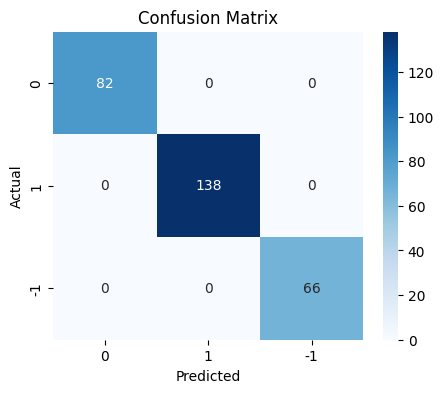

In [ ]:
plot_confusion_matrix(base_wv,X_train_wv,y_train)

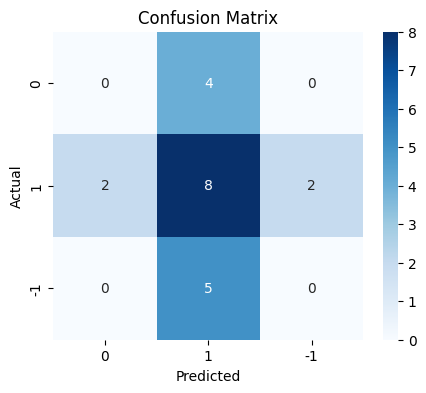

In [ ]:
plot_confusion_matrix(base_wv,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
base_train_wv = model_performance_classification_sklearn(base_wv,X_train_wv,y_train)
print("Training performance:\n", base_train_wv)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_wv = model_performance_classification_sklearn(base_wv,X_val_wv,y_val)
print("Validation performance:\n",base_val_wv)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.380952  0.380952   0.268908  0.315271


**Observation:**

Recall , precision,F1 and Accurarcy values are good on Traing data but not good at Validation data.

Model is Overfitting Model

**GradientBoostingClassifier**

In [ ]:
# Building the model

#Uncomment only one of the snippets related to fitting the model to the data

base_wv1 = GradientBoostingClassifier(random_state = 42)
#base_wv = RandomForestClassifier(random_state=42)
#base_wv = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_wv1.fit(X_train_wv, y_train)

GradientBoostingClassifier(random_state=42)

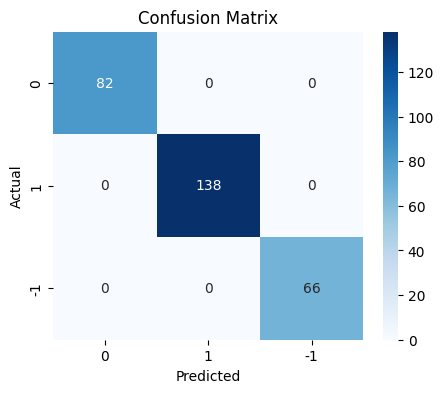

In [ ]:
plot_confusion_matrix(base_wv1,X_train_wv,y_train)

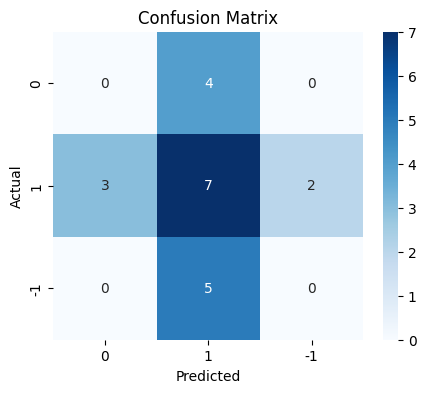

In [ ]:
plot_confusion_matrix(base_wv1,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
base_train_wv1 = model_performance_classification_sklearn(base_wv1,X_train_wv,y_train)
print("Training performance:\n", base_train_wv1)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_wv1 = model_performance_classification_sklearn(base_wv1,X_val_wv,y_val)
print("Validation performance:\n",base_val_wv1)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.333333  0.333333       0.25  0.285714


**Observation:**

Recall , precision,F1 and Accurarcy values are good on Traing data but not good at Validation data.

Model is Overfitting Model


**Base Model - GloVe**

**RandomForestClassifier with Glv**

In [ ]:
#Building the model

#Uncomment only one of the snippets related to fitting the model to the data

#base_Glv1 = GradientBoostingClassifier(random_state = 42)
base_Glv = RandomForestClassifier(random_state=42)
#base_Glv2 = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_Glv.fit(X_train_gl, y_train) #Complete the code to fit the chosen model on the train data

RandomForestClassifier(random_state=42)

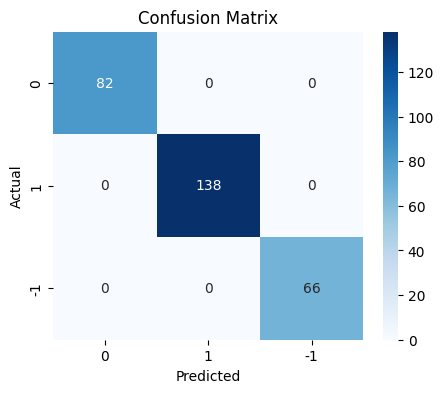

In [ ]:
plot_confusion_matrix(base_Glv,X_train_gl,y_train) #Complete the code to plot the confusion matrix for the train data

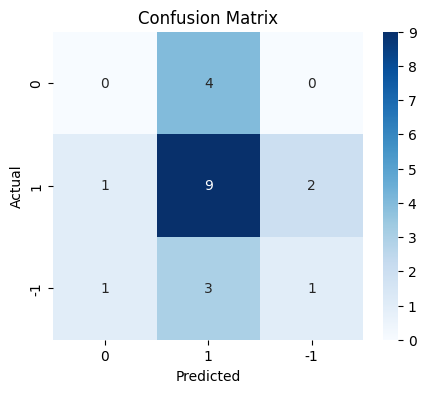

In [ ]:
plot_confusion_matrix(base_Glv,X_val_gl,y_val) #Complete the code to plot the confusion matrix for the validation data

In [ ]:
#Calculating different metrics on training data
base_train_gl=model_performance_classification_sklearn(base_Glv,X_train_gl,y_train) #Complete the code to compute the model performance for the training data
print("Training performance:\n", base_train_gl)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_gl = model_performance_classification_sklearn(base_Glv,X_val_gl,y_val) #Complete the code to compute the model performance for the validation data
print("Validation performance:\n",base_val_gl)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.47619  0.47619   0.400794  0.426871


**Observation:**

Recall , precision,F1 and Accurarcy values are good on Traing data but not good at Validation data.

Model is Overfitting Model, Still Randomforest clasifier is performing better than other clasifiers.

**GradientBoostingClassifier with Glove**


In [ ]:
#Building the model

#Uncomment only one of the snippets related to fitting the model to the data

base_Glv1 = GradientBoostingClassifier(random_state = 42)
#base_Glv = RandomForestClassifier(random_state=42)
#base_Glv2 = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_Glv1.fit(X_train_gl, y_train) #Complete the code to fit the chosen model on the train data

GradientBoostingClassifier(random_state=42)

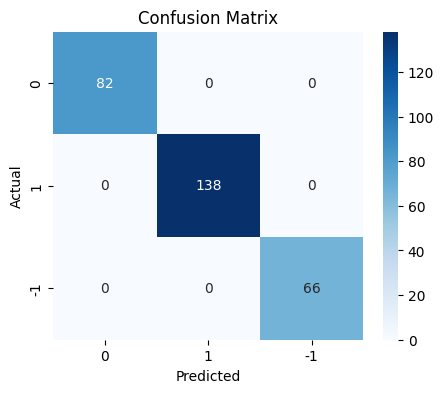

In [ ]:
plot_confusion_matrix(base_Glv1,X_train_gl,y_train) #Complete the code to plot the confusion matrix for the train data

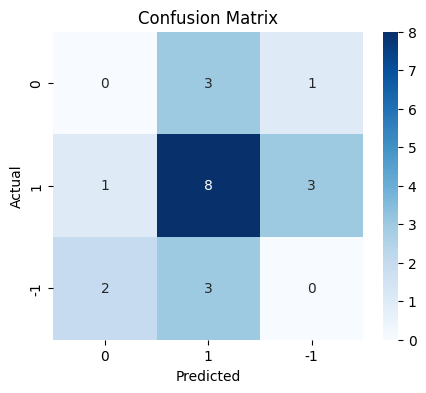

In [ ]:
plot_confusion_matrix(base_Glv1,X_val_gl,y_val) #Complete the code to plot the confusion matrix for the validation data

In [ ]:
#Calculating different metrics on training data
base_train_gl1=model_performance_classification_sklearn(base_Glv1,X_train_gl,y_train) #Complete the code to compute the model performance for the training data
print("Training performance:\n", base_train_gl1)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_gl1 = model_performance_classification_sklearn(base_Glv1,X_val_gl,y_val) #Complete the code to compute the model performance for the validation data
print("Validation performance:\n",base_val_gl1)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.380952  0.380952   0.326531  0.351648


**Observation:**

Recall , precision,F1 and Accurarcy values are good on Traing data but not good at Validation data.

Model is Overfitting Model

**Base Model - Sentence Transformer**

**GradientBoostingClassifier**

In [ ]:
# Building the model

#Uncomment only one of the snippets related to fitting the model to the data

base_st1 = GradientBoostingClassifier(random_state = 42)
#base_st = RandomForestClassifier(random_state=42)
#base_st2 = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_st1.fit(X_train_st, y_train) #Complete the code to fit the chosen model on the train data

GradientBoostingClassifier(random_state=42)

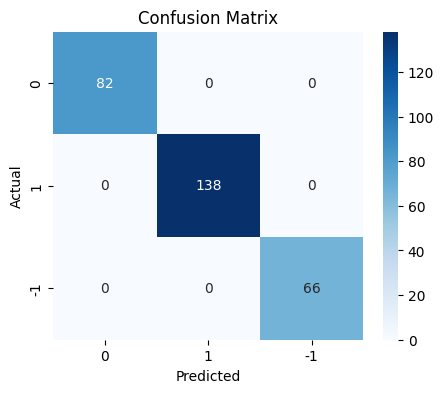

In [ ]:
plot_confusion_matrix(base_st1,X_train_st,y_train) #Complete the code to plot the confusion matrix for the train data

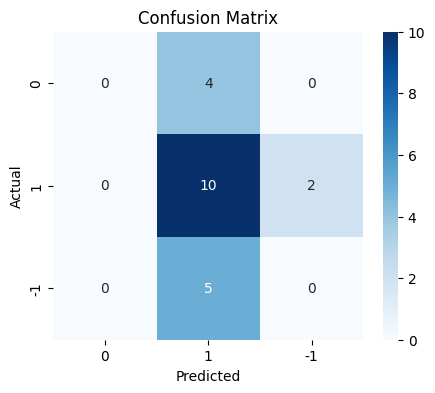

In [ ]:
plot_confusion_matrix(base_st1,X_val_st,y_val) #Complete the code to plot the confusion matrix for the validation data

In [ ]:
#Calculating different metrics on training data
base_train_st1_GB=model_performance_classification_sklearn(base_st1,X_train_st,y_train) #Complete the code to compute the model performance for the training data
print("Training performance:\n", base_train_st1_GB)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_st1_GB = model_performance_classification_sklearn(base_st1,X_val_st,y_val) #Complete the code to compute the model performance for the validation data
print("Validation performance:\n",base_val_st1_GB)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.47619  0.47619   0.300752  0.368664


**Observation:**

Recall , precision,F1 and Accurarcy values are good on Traing data but not good at Validation data.

Model is Overfitting Model.

**RandomForestClassifier with sentance Transfer**

In [ ]:
# Building the model

#Uncomment only one of the snippets related to fitting the model to the data

#base_st1 = GradientBoostingClassifier(random_state = 42)
base_st = RandomForestClassifier(random_state=42)
#base_st2 = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_st.fit(X_train_st, y_train) #Complete the code to fit the chosen model on the train data

RandomForestClassifier(random_state=42)

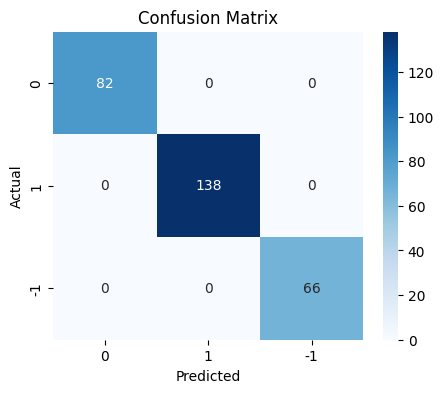

In [ ]:
plot_confusion_matrix(base_st,X_train_st,y_train) #Complete the code to plot the confusion matrix for the train data

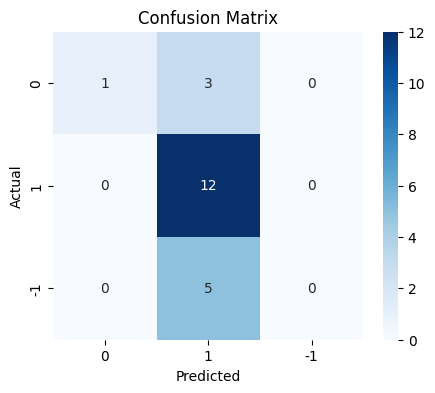

In [ ]:
plot_confusion_matrix(base_st,X_val_st,y_val) #Complete the code to plot the confusion matrix for the train data

In [ ]:
#Calculating different metrics on training data
base_train_st1_RF=model_performance_classification_sklearn(base_st,X_train_st,y_train) #Complete the code to compute the model performance for the training data
print("Training performance:\n", base_train_st1_RF)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on training data
base_val_st1_RF=model_performance_classification_sklearn(base_st,X_val_st,y_val) #Complete the code to compute the model performance for the training data
print("Training performance:\n", base_val_st1_RF)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.619048  0.619048   0.533333  0.504762


**Observation:**

Recall , precision,F1 and Accurarcy values are good on Traing data but not good at Validation data, Validation Recall and accurry is better than other models

Model is Overfitting Model, Still Randomforest clasifier with sentance is performing better than other models.

### Tuned Model - Word2Vec

**Note**: The parameter grid provided below is a sample grid. It can be modified depending on the compute power of the system being used.

**GradientBoostingClassifier**

In [ ]:
start = time.time()

# Choose the type of classifier.

#Uncomment only one of the snippets corrrsponding to the base model trained previously

tuned_wv1_GD = GradientBoostingClassifier(random_state = 42)
#tuned_wv = RandomForestClassifier(random_state=42)
#tuned_wv2 = DecisionTreeClassifier(random_state=42)


parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_wv1_GD, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_wv, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_wv1_GD = grid_obj.best_estimator_

Time taken  498.1677210330963


In [ ]:
# Fit the best algorithm to the data.
tuned_wv1_GD.fit(X_train_wv, y_train)

GradientBoostingClassifier(max_depth=5, max_features='sqrt',
                           min_samples_split=9, random_state=42)

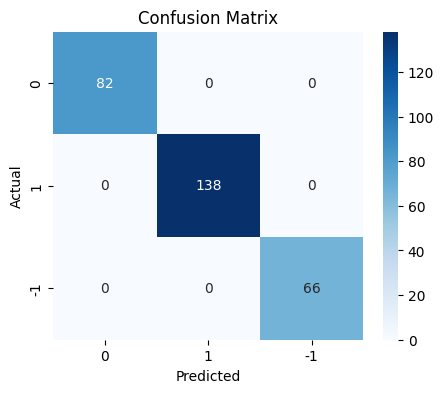

In [ ]:
plot_confusion_matrix(tuned_wv1_GD,X_train_wv,y_train)

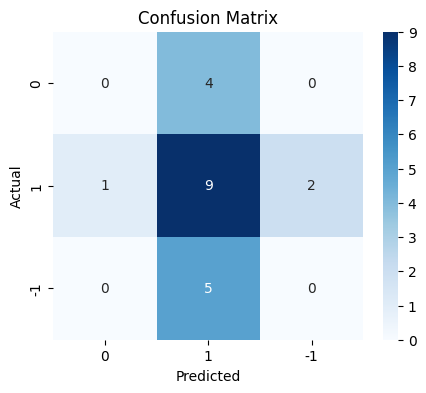

In [ ]:
plot_confusion_matrix(tuned_wv1_GD,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
tuned_train_wv1_GD=model_performance_classification_sklearn(tuned_wv1_GD,X_train_wv,y_train)
print("Training performance:\n",tuned_train_wv1_GD)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
tuned_val_wv1_GD = model_performance_classification_sklearn(tuned_wv1_GD,X_val_wv,y_val)
print("Validation performance:\n",tuned_val_wv1_GD)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.428571  0.428571   0.285714  0.342857


**Observation:**

Recall , precision,F1 and Accurarcy values are good on Traing data but not good at Validation data.

Validation Accuracy and Recall Value on Validation data = 0.47

**RandomForestClassifier**

In [ ]:
start = time.time()

# Choose the type of classifier.

#Uncomment only one of the snippets corrrsponding to the base model trained previously

#tuned_wv1_GD = GradientBoostingClassifier(random_state = 42)
tuned_wv_RF = RandomForestClassifier(random_state=42)
#tuned_wv2 = DecisionTreeClassifier(random_state=42)


parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_wv_RF, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_wv, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_wv_RF = grid_obj.best_estimator_

Time taken  129.18964266777039


In [ ]:
# Fit the best algorithm to the data.
tuned_wv_RF.fit(X_train_wv, y_train)

RandomForestClassifier(max_depth=6, max_features='log2', min_samples_split=11,
                       random_state=42)

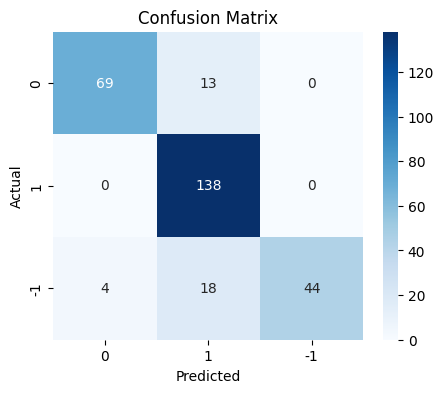

In [ ]:
plot_confusion_matrix(tuned_wv_RF,X_train_wv,y_train)

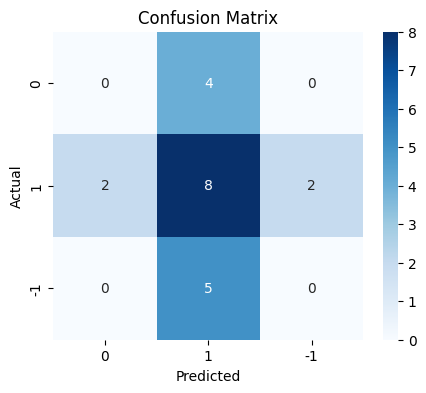

In [ ]:
plot_confusion_matrix(tuned_wv_RF,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
tuned_train_wv_RF=model_performance_classification_sklearn(tuned_wv_RF,X_train_wv,y_train)
print("Training performance:\n",tuned_train_wv_RF)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.877622  0.877622   0.895781  0.873677


In [ ]:
#Calculating different metrics on training data
tuned_val_wv_RF=model_performance_classification_sklearn(tuned_wv_RF,X_val_wv,y_val)
print("Training performance:\n",tuned_val_wv_RF)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.380952  0.380952   0.268908  0.315271


With Tunned RF Clasiffiered model ,Recall , precision,F1 and Accurarcy values are good on Traing data but not good at Validation data.

Validation Accuracy and Recall Value on Validation data = 0.47

### Tuned Model - GloVe

**GradientBoostingClassifier**

In [ ]:
start = time.time()

#Uncomment only one of the snippets corrrsponding to the base model trained previously

tuned_glv1_GD = GradientBoostingClassifier(random_state = 42)
#tuned_wv = RandomForestClassifier(random_state=42)
#tuned_wv = DecisionTreeClassifier(random_state=42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_glv1_GD, parameters, scoring='f1_weighted',cv=5,n_jobs=-1) #Complete the code to pass the chosen model
grid_obj = grid_obj.fit(X_train_gl, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_glv1_GD = grid_obj.best_estimator_

Time taken  250.66737413406372


In [ ]:
# Fit the best algorithm to the data.
tuned_glv1_GD.fit(X_train_gl, y_train) #Complete the code to fit the chosen model on the train data

GradientBoostingClassifier(max_features='log2', min_samples_split=9,
                           random_state=42)

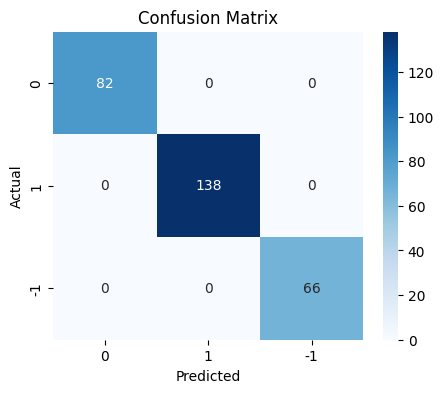

In [ ]:
plot_confusion_matrix(tuned_glv1_GD,X_train_gl,y_train) #Complete the code to plot the confusion matrix for the train data

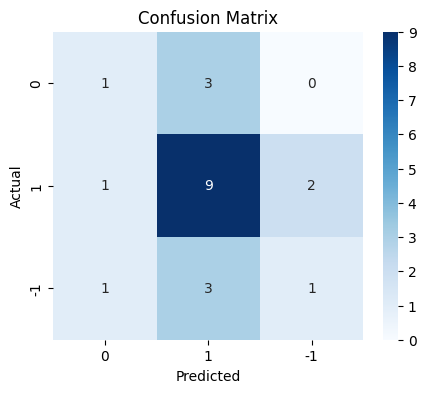

In [ ]:
plot_confusion_matrix(tuned_glv1_GD,X_val_gl,y_val) #Complete the code to plot the confusion matrix for the validation data

In [ ]:
#Calculating different metrics on training data
tuned_train_gl_GD=model_performance_classification_sklearn(tuned_glv1_GD,X_train_gl,y_train) #Complete the code to compute the model performance for the training data
print("Training performance:\n",tuned_train_gl_GD)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
tuned_val_gl_GD = model_performance_classification_sklearn(tuned_glv1_GD,X_val_gl,y_val) #Complete the code to compute the model performance for the validation data
print("Validation performance:\n",tuned_val_gl_GD)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.52381  0.52381   0.485714  0.494898


**Observation:**
Tuned Model - GloVe with GB Model Recall , precision,F1 and Accurarcy values are good on Traing data but Validation data shows slight improvment with Tunned Glove model.

Validation Accuracy and Recall Value on Validation data = 0.52

**RandomForestClassifier**

In [ ]:
start = time.time()

#Uncomment only one of the snippets corrrsponding to the base model trained previously

#tuned_glv1_GD = GradientBoostingClassifier(random_state = 42)
tuned_glv_RF = RandomForestClassifier(random_state=42)
#tuned_glv2_DT = DecisionTreeClassifier(random_state=42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_glv_RF, parameters, scoring='f1_weighted',cv=5,n_jobs=-1) #Complete the code to pass the chosen model
grid_obj = grid_obj.fit(X_train_gl, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_glv_RF = grid_obj.best_estimator_

Time taken  73.24103569984436


In [ ]:
# Fit the best algorithm to the data.
tuned_glv_RF.fit(X_train_gl, y_train) #Complete the code to fit the chosen model on the train data

RandomForestClassifier(max_depth=6, max_features=0.2, min_samples_split=7,
                       random_state=42)

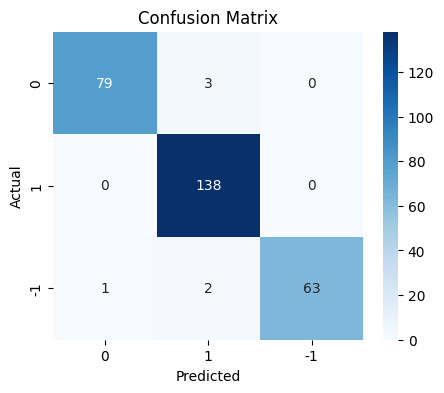

In [ ]:
plot_confusion_matrix(tuned_glv_RF,X_train_gl,y_train) #Complete the code to plot the confusion matrix for the train data

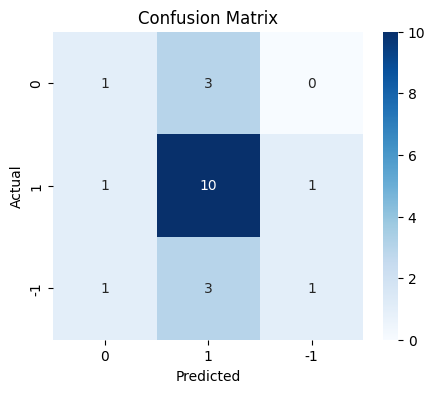

In [ ]:
plot_confusion_matrix(tuned_glv_RF,X_val_gl,y_val) #Complete the code to plot the confusion matrix for the train data

In [ ]:
#Calculating different metrics on training data
tuned_train_gl_RF=model_performance_classification_sklearn(tuned_glv_RF,X_train_gl,y_train) #Complete the code to compute the model performance for the training data
print("Training performance:\n",tuned_train_gl_RF)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.979021  0.979021   0.979545  0.978968


In [ ]:
#Calculating different metrics on validation data
tuned_val_gl_RF = model_performance_classification_sklearn(tuned_glv_RF,X_val_gl,y_val) #Complete the code to compute the model performance for the validation data
print("Validation performance:\n",tuned_val_gl_RF)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.571429  0.571429   0.539683  0.530612


**Observation:**

Tuned Model - GloVe with RF Model Recall , precision,F1 and Accurarcy values are good on Traing data but Validation data shows slight improvment with Tunned Glove RF model.

Validation Accuracy and Recall Value on Validation data = 0.57

### Tuned Model - Sentence Transformer

**GradientBoostingClassifier**

In [ ]:
start = time.time()

# Choose the type of classifier.

#Uncomment only one of the snippets corrrsponding to the base model trained previously

tuned_st_GD = GradientBoostingClassifier(random_state = 42)
#tuned_st_RF = RandomForestClassifier(random_state=42)
#tuned_st_DT = DecisionTreeClassifier(random_state=42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_st_GD, parameters, scoring='f1_weighted',cv=5,n_jobs=-1) #Complete the code to pass the chosen model
grid_obj = grid_obj.fit(X_train_st, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_st_GD = grid_obj.best_estimator_

Time taken  610.7955827713013


In [ ]:
# Fit the best algorithm to the data.
tuned_st_GD.fit(X_train_st, y_train) #Complete the code to fit the chosen model on the train data

GradientBoostingClassifier(max_features='sqrt', min_samples_split=11,
                           random_state=42)

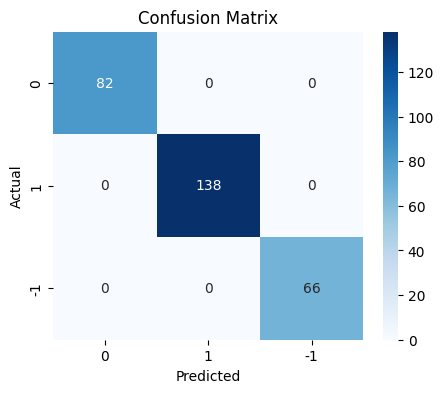

In [ ]:
plot_confusion_matrix(tuned_st_GD,X_train_st,y_train) #Complete the code to plot the confusion matrix for the train data

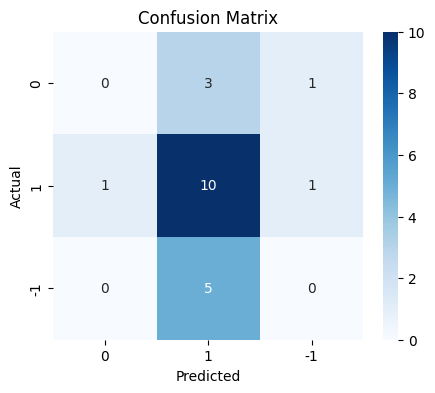

In [ ]:
plot_confusion_matrix(tuned_st_GD,X_val_st,y_val) #Complete the code to plot the confusion matrix for the validation data

In [ ]:
#Calculating different metrics on training data
tuned_train_st_GD=model_performance_classification_sklearn(tuned_st_GD,X_train_st,y_train) #Complete the code to compute the model performance for the training data
print("Training performance:\n",tuned_train_st_GD)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
tuned_val_st_GD = model_performance_classification_sklearn(tuned_st_GD,X_val_st,y_val) #Complete the code to compute the model performance for the validation data
print("Validation performance:\n",tuned_val_st_GD)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.47619  0.47619    0.31746  0.380952


**Observation:**
Tuned Model - Sentance Transformer with GB Model Recall , precision,F1 and Accurarcy values are good on Traing data but Validation data recall is not good

Validation Accuracy and Recall Value on Validation data = 0.47

**RandomForestClassifier**

In [ ]:
start = time.time()

# Choose the type of classifier.

#Uncomment only one of the snippets corrrsponding to the base model trained previously

#tuned_st_GD = GradientBoostingClassifier(random_state = 42)
tuned_st_RF = RandomForestClassifier(random_state=42)
#tuned_st_DT = DecisionTreeClassifier(random_state=42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_st_RF, parameters, scoring='f1_weighted',cv=5,n_jobs=-1) #Complete the code to pass the chosen model
grid_obj = grid_obj.fit(X_train_st, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_st_RF = grid_obj.best_estimator_

Time taken  155.17376589775085


In [ ]:
# Fit the best algorithm to the data.
tuned_st_RF.fit(X_train_st, y_train) #Complete the code to fit the chosen model on the train data

RandomForestClassifier(max_depth=6, max_features=0.2, min_samples_split=11,
                       random_state=42)

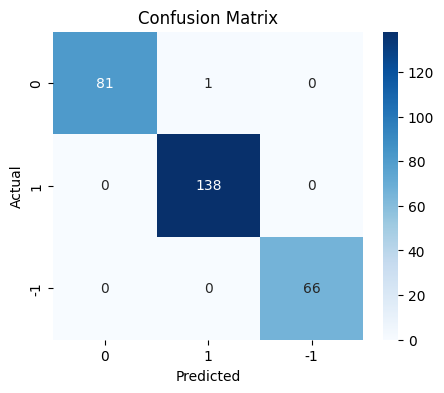

In [ ]:
plot_confusion_matrix(tuned_st_RF,X_train_st,y_train) #Complete the code to plot the confusion matrix for the train data

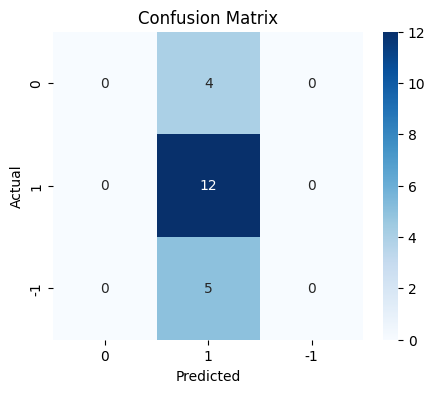

In [ ]:
plot_confusion_matrix(tuned_st_RF,X_val_st,y_val) #Complete the code to plot the confusion matrix for the validation data

In [ ]:
#Calculating different metrics on training data
tuned_train_st_RF=model_performance_classification_sklearn(tuned_st_RF,X_train_st,y_train) #Complete the code to compute the model performance for the training data
print("Training performance:\n",tuned_train_st_RF)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.996503  0.996503   0.996529  0.996499


In [ ]:
#Calculating different metrics on validation data
tuned_val_st_RF = model_performance_classification_sklearn(tuned_st_RF,X_val_st,y_val) #Complete the code to compute the model performance for the validation data
print("Validation performance:\n",tuned_val_st_RF)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.571429  0.571429   0.326531  0.415584


**Observation:**
Tuned Model - Sentance Transformer with RF Model Recall , precision,F1 and Accurarcy values are good on Traing data but Validation data shows slight improvment with Tunned Sentance Transformer of RF.

Validation Accuracy and Recall Value on Validation data = 0.57

### Model Performance Summary and Final Model Selection

In [ ]:
#training performance comparison

models_train_comp_df = pd.concat(
    [base_train_wv.T,
     base_train_wv1.T,
      base_train_gl.T,
     base_train_gl1.T,
     base_train_st1_GB.T,
     base_train_st1_RF.T,
     tuned_train_wv1_GD.T,
     tuned_train_wv_RF.T,
     tuned_train_gl_GD.T,
     tuned_train_gl_RF.T,
     tuned_train_st_GD.T,
     tuned_train_st_RF.T,
     ],axis=1
)

# The DataFrame models_train_comp_df has 18 columns.
#Therefore, we need to provide 18 column names instead of 6.
# Creating a list with 18 column names to match the number of columns in the DataFrame.
models_train_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (Word2Vec1)",
    "Base Model (GloVe)",
    "Base Model (GloVe1)",
    "Base Model (Sentence Transformer GB)",
    "Base Model (Sentence Transformer RF)",
    "Tuned Model (Word2Vec GD)",
    "Tuned Model (Word2Vec RF)",
    "Tuned Model (GloVe GD)",
    "Tuned Model (GloVe RF)",
    "Tuned Model (Sentence Transformer GD)",
    "Tuned Model (Sentence Transformer RF)",

]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Base Model (Word2Vec),Base Model (Word2Vec1),Base Model (GloVe),Base Model (GloVe1),Base Model (Sentence Transformer GB),Base Model (Sentence Transformer RF),Tuned Model (Word2Vec GD),Tuned Model (Word2Vec RF),Tuned Model (GloVe GD),Tuned Model (GloVe RF),Tuned Model (Sentence Transformer GD),Tuned Model (Sentence Transformer RF)
Accuracy,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.877622,1.0,0.979021,1.0,0.996503
Recall,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.877622,1.0,0.979021,1.0,0.996503
Precision,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.895781,1.0,0.979545,1.0,0.996529
F1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.873677,1.0,0.978968,1.0,0.996499


In [ ]:
#validation performance comparison

# Create the DataFrame and assign it to models_val_comp_df
models_val_comp_df = pd.concat(
    [base_val_wv.T,
     base_val_wv1.T,
     base_val_gl.T,
     base_val_gl1.T,
     base_val_st1_GB.T,
     base_val_st1_RF.T,
     tuned_val_wv1_GD.T,
     tuned_val_wv_RF.T,
     tuned_val_gl_GD.T,
     tuned_val_gl_RF.T,
     tuned_val_st_GD.T,
     tuned_val_st_RF.T,

    ],axis=1
)

# Now you can set the columns
models_val_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (Word2Vec1)",
    "Base Model (GloVe)",
    "Base Model (GloVe1)",
    "Base Model (Sentence Transformer GB)",
    "Base Model (Sentence Transformer RF)",
    "Tuned Model (Word2Vec GD)",
    "Tuned Model (Word2Vec RF)",
    "Tuned Model (GloVe GD)",
    "Tuned Model (GloVe RF)",
    "Tuned Model (Sentence Transformer GD)",
    "Tuned Model (Sentence Transformer RF)",

]

print("Validation performance comparison:")
models_val_comp_df


Validation performance comparison:


,Base Model (Word2Vec),Base Model (Word2Vec1),Base Model (GloVe),Base Model (GloVe1),Base Model (Sentence Transformer GB),Base Model (Sentence Transformer RF),Tuned Model (Word2Vec GD),Tuned Model (Word2Vec RF),Tuned Model (GloVe GD),Tuned Model (GloVe RF),Tuned Model (Sentence Transformer GD),Tuned Model (Sentence Transformer RF)
Accuracy,0.380952,0.333333,0.476190,0.380952,0.476190,0.619048,0.428571,0.380952,0.523810,0.571429,0.476190,0.571429
Recall,0.380952,0.333333,0.476190,0.380952,0.476190,0.619048,0.428571,0.380952,0.523810,0.571429,0.476190,0.571429
Precision,0.268908,0.250000,0.400794,0.326531,0.300752,0.533333,0.285714,0.268908,0.485714,0.539683,0.317460,0.326531
F1,0.315271,0.285714,0.426871,0.351648,0.368664,0.504762,0.342857,0.315271,0.494898,0.530612,0.380952,0.415584


**Summary of Observation:**

Based on the performance metrics from running:

GradientBoostClassifier with W2V,Glove and Sentance Transformer
RandomForestClassifier  with W2V,Glove and Sentance Transformer

The RandomForestClassifier with Base and Tuned Model (Sentence Transformer) is the best models. It has the highest validation accuracy, recall, precision, and F1 score among the models tested.

Training Performance on Base Model with RF: The model achieves perfect scores (1.0) for accuracy, recall, precision, and F1 on the training data.
Validation Performance on Base Model with RF: The model achieves the highest validation accuracy (0.619), recall (0.619), precision (0.533), and F1 score (0.50) from the different models tested.

Training Performance on Tunned Sentance Transformer Model with RF: The model achieves perfect scores (0.997) for accuracy, recall, precision, and F1 on the training data.
Validation Performance on Tunned sentance Transformer Model with RF: The model achieves the highest validation accuracy (0.57), recall (0.57), precision (0.32), and F1 score (0.41) from the different models tested.

Training Performance on Tunned Glove Model with RF: The model achieves perfect scores (0.97) for accuracy, recall, precision, and F1 on the training data. Validation Performance on Tunned sentance Transformer Model with RF: The model achieves the highest validation accuracy (0.57), recall (0.57), precision (0.0.53), and F1 score (0.53) from the different models tested.

The RandomForestClassifier with Base and Tunned Model (Sentence Transformer&Glove) generalizes well to new, unseen data and is the most effective models for this task.

### Model Performance Check on Test Data

**Sentance Transformer with RF Tunned on Test data**

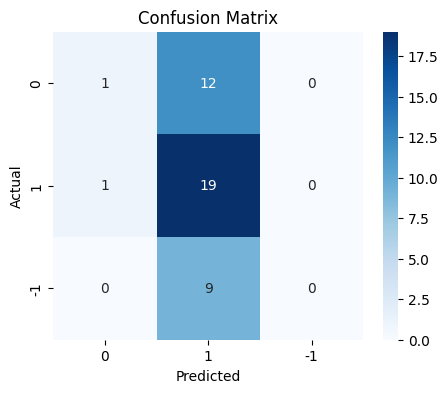

In [ ]:
plot_confusion_matrix(tuned_st_RF,X_test_st,y_test) #Complete the code to plot the confusion matrix for the final model and test data

In [ ]:
#Calculating different metrics on training data
final_model_test = model_performance_classification_sklearn(tuned_st_RF,X_test_st,y_test) #Complete the code to compute the final model's performance for the test data
print("Test performance for the final model:\n",final_model_test)

Test performance for the final model:
    Accuracy   Recall  Precision        F1
0   0.47619  0.47619   0.380952  0.342857


**Tunned Glove with Random Forest Test data**

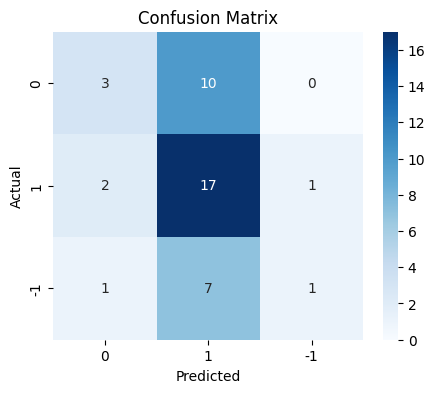

In [ ]:
plot_confusion_matrix(tuned_glv_RF,X_test_gl,y_test) #Complete the code to plot the confusion matrix for the final model and test data

In [ ]:
#Calculating different metrics on training data
final_model_test = model_performance_classification_sklearn(tuned_glv_RF,X_test_gl,y_test) #Complete the code to compute the final model's performance for the test data
print("Test performance for the final model:\n",final_model_test)

Test performance for the final model:
    Accuracy  Recall  Precision        F1
0       0.5     0.5        0.5  0.436529


**Sentance Transformer with Random Forest - Base Model**

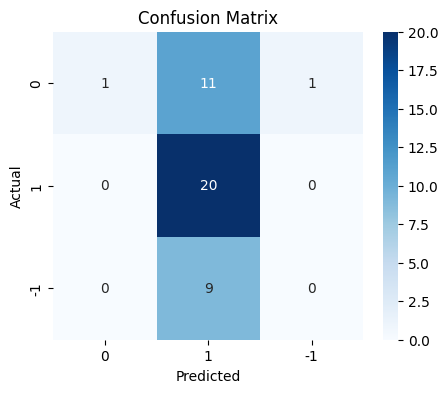

In [ ]:
plot_confusion_matrix(base_st,X_test_st,y_test) #Complete the code to plot the confusion matrix for the final model and test data

In [ ]:
#Calculating different metrics on training data
final_model_test = model_performance_classification_sklearn(base_st,X_test_st,y_test) #Complete the code to compute the final model's performance for the test data
print("Test performance for the final model:\n",final_model_test)

Test performance for the final model:
    Accuracy  Recall  Precision        F1
0       0.5     0.5   0.547619  0.361678


**Observation:**

Final selected Models Base RF with Sentance Transfer and Tunned RF with Glove Models are given same results on test data.

Accuracy :0.5
Recall:  0.5
Precision: 05
F1 score : F1 Score has Slight defference

F1 Score of Tunned Model on Test :0.43
F1 Score of Based Model on Test: 0.36




## **Weekly News Summarization**

**Important Note**: It is recommended to run this section of the project independently from the previous sections in order to avoid runtime crashes due to RAM overload.

#### Installing and Importing the necessary libraries

In [ ]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
#!CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python -q

In [ ]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

from tqdm import tqdm # For progress bar related functionalities
tqdm.pandas()

#### Loading the data

In [ ]:
stock_news = pd.read_csv("/content/drive/MyDrive/NLP/project/stock_news.csv") #Complete the code to load the dataset

In [ ]:
data = stock_news.copy()

In [ ]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


#### Loading the model

In [ ]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"


model_path = hf_hub_download(
    repo_id=model_name_or_path, # Complete the code to mention the repo_id
    filename=model_basename # Complete the code to mention the filename
)

mistral-7b-instruct-v0.2.Q6_K.gguf:   0%|          | 0.00/5.94G [00:00<?, ?B/s]

In [ ]:
#uncomment the below snippet of code if the runtime is connected to GPU.
llm = Llama(
    model_path=model_path, # Path to the model
    n_gpu_layers=100, #Number of layers transferred to GPU
    n_ctx=4500, #Context window
)

AVX = 1 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 1 | SSE3 = 1 | SSSE3 = 1 | VSX = 0 | 


In [ ]:
# uncomment and run the following code in case GPU is not being used

# llm = Llama(
#     model_path=model_path,
#     n_ctx=4500, # Context window
#     n_cores=-2 # Number of CPU cores to use
# )

#### Aggregating the data weekly

In [ ]:
data["Date"] = pd.to_datetime(data['Date'])  # Convert the 'Date' column to datetime format.

In [ ]:
# Group the data by week using the 'Date' column.
weekly_grouped = data.groupby(pd.Grouper(key='Date', freq='W'))

In [ ]:
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

(18, 2)


In [ ]:
weekly_grouped

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an..."
6,2019-02-17,"This week, the European Union's second highes..."
7,2019-02-24,This news article discusses progress towards ...
8,2019-03-03,The Dow Jones Industrial Average and other ma...
9,2019-03-10,"Spotify, the world's largest paid music strea..."


In [ ]:
# creating a copy of the data
data_1 = weekly_grouped.copy()

In [ ]:

data_1.head(5)

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...


#### Summarization

**Note**:

- The model is expected to summarize the news from the week by identifying the top three positive and negative events that are most likely to impact the price of the stock.

- As an output, the model is expected to return a JSON containing two keys, one for Positive Events and one for Negative Events.

For the project, we need to define the prompt to be fed to the LLM to help it understand the task to perform. The following should be the components of the prompt:

1. **Role**: Specifies the role the LLM will be taking up to perform the specified task, along with any specific details regarding the role

  - **Example**: `You are an expert data analyst specializing in news content analysis.`

2. **Task**: Specifies the task to be performed and outlines what needs to be accomplished, clearly defining the objective

  - **Example**: `Analyze the provided news headline and return the main topics contained within it.`

3. **Instructions**: Provides detailed guidelines on how to perform the task, which includes steps, rules, and criteria to ensure the task is executed correctly

  - **Example**:

```
Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.
```

4. **Output Format**: Specifies the format in which the final response should be structured, ensuring consistency and clarity in the generated output

  - **Example**: `Return the output in JSON format with keys as the topic number and values as the actual topic.`

**Full Prompt Example**:

```
You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
```

**Sample Output**:

`{"1": "Politics", "2": "Economy", "3": "Health" }`

##### Utility Functions

In [ ]:
# defining a function to parse the JSON output from the model
def extract_json_data(json_str):
    import json
    try:
        # Find the indices of the opening and closing curly braces
        json_start = json_str.find('{')
        json_end = json_str.rfind('}')

        if json_start != -1 and json_end != -1:
            extracted_category = json_str[json_start:json_end + 1]  # Extract the JSON object
            data_dict = json.loads(extracted_category)
            return data_dict
        else:
            print(f"Warning: JSON object not found in response: {json_str}")
            return {}
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return {}

##### Defining the response function

In [ ]:
#Defining the response function
def response_mistral_1(prompt, news):
    model_output = llm(
      f"""
      [INST]
      {prompt}
      News Articles: {news}
      [/INST]
      """,
      max_tokens=1024,
      temperature=0.7,
      top_p=0.9,
      top_k=50,
      echo=False,
    )

    final_output = model_output["choices"][0]["text"]

    return final_output

**max_tokens:**This parameter specifies the maximum number of tokens that the model should generate in response to the prompt.

**temperature:** This parameter controls the randomness of the generated response. A higher temperature value will result in a more random response, while a lower temperature value will result in a more predictable response.

**top_p:** This parameter controls the diversity of the generated response by establishing a cumulative probability cutoff for token selection. A higher value of top_p will result in a more diverse response, while a lower value will result in a less diverse response.
**top_k:** This parameter controls the maximum number of most-likely next tokens to consider when generating the response at each step.

**stop:** This parameter is a list of tokens that are used to dynamically stop response generation whenever the tokens in the list are encountered.

**echo:** This parameter controls whether the input (prompt) to the model should be returned in the model response.

**Note**: Use this section to test out the prompt with one instance before using it for the entire weekly data.

In [ ]:
news = data_1.loc[0, 'News']

In [ ]:
print(len(news.split(' ')))
news

2611


' The tech sector experienced a significant decline in the aftermarket following Apple\'s Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple\'s downward revision of its revenue expectations for the quarter, previously announced in January. ||  Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple\'s stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10 ||  Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple\'s shares fell 8.5% in post market trading, while Asian suppliers like Hon ||  This news article reports that yields o

In [ ]:
#Print columns which arec responsed
print("Columns in model_response_parsed:", data_1.columns)

Columns in model_response_parsed: Index(['Date', 'News'], dtype='object')


In [ ]:
data_1.head(5)

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...


In [ ]:
#Complete the code to define the prompt for this task
prompt = """
    Analyze the news headlines and determine which news articles are positive or negative in sentiment
"""

In [ ]:
%%time
summary = response_mistral_1(prompt, news)
print(summary)

1. Negative: Apple's Q1 revenue warning led to significant declines in Apple's stock price and negative impacts on related suppliers, causing broader market declines for tech indices such as Nasdaq 10, USD JPY pair gains, and risk aversion mood in markets.
      2. Negative: Concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown led to a decrease in yields on long-term U.S. Treasury securities.
      3. Negative: Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency.
      4. Negative: The tech giant's suppliers and S&P 500 futures suffered losses due to Apple's underperformance in Q1 and fears of a global economic slowdown following the revenue warning.
      5. Negative: The Australian dollar experienced significant volatility on Thursday, plunging to multi-year lows against major currencies due to automat

##### Checking the model output on the weekly data

In [ ]:
%%time
data_1['Key Events'] = data_1['News'].progress_apply(lambda x: response_mistral_1(prompt,x))

100%|██████████| 18/18 [10:55<00:00, 36.41s/it]

CPU times: user 10min 30s, sys: 22.2 s, total: 10min 52s
Wall time: 10min 55s


In [ ]:
data_1["Key Events"].head(5) #Complete the code to print the first 5 rows of the 'Key_Events' column

,Key Events
0,1. Negative: Apple's Q1 revenue warning led to...
1,1. Sprint and Samsung plan to release 5G smart...
2,1. The U.S. stock market declined on Monday as...
3,1. Switzerland: Neutral - The news article rep...
4,1. Caterpillar Inc: Negative - The headline me...


##### Formatting the model output

In [ ]:
data_1['model_response_parsed'] = data_1['Key Events'].apply(extract_json_data)
data_1.head()

      2. Negative: Apple cut its fiscal first quarter revenue forecast due to weaker demand in China and fewer iPhone upgrades, leading to a significant drop in Apple's stock price and impacting related suppliers. This news also triggered risk aversion mood in markets, causing losses for S&P 500 futures.
      3. Negative: Fears of a global economic slowdown following weak economic data from China and Europe, as well as the partial U.S. government shutdown, led to a decline in long-dated US Treasury securities' yields to their lowest levels in nearly a year. Apple's underperformance also contributed to this trend.
      4. Negative: Apple's revenue warning caused significant volatility in the currency markets, leading to gains for the Japanese yen as investors sought safety. The USD JPY pair dropped significantly following the news.
      5. Negative: Apple's underperformance and the resulting market declines led to a drop in long-term US Treasury yields below 2.6%, as investors shifte

,Date,News,Key Events,model_response_parsed
0,2019-01-06,The tech sector experienced a significant dec...,1. Negative: Apple's Q1 revenue warning led to...,{}
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,1. Sprint and Samsung plan to release 5G smart...,{}
2,2019-01-20,The U.S. stock market declined on Monday as c...,1. The U.S. stock market declined on Monday as...,{}
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...",1. Switzerland: Neutral - The news article rep...,{}
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,1. Caterpillar Inc: Negative - The headline me...,{}


In [ ]:
model_response_parsed = pd.json_normalize(data_1['model_response_parsed'])
model_response_parsed.head()

""
0
1
2
3
4


In [ ]:
final_output = pd.concat([data_1.reset_index(drop=True),model_response_parsed],axis=1)
final_output.drop(['Key Events','model_response_parsed'], axis=1, inplace=True)
final_output.columns = ['Week End Date', 'News']

final_output.head()

,Week End Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...


**Conclusions and Recommendations**

Recommendation for model is the RandomForestClassifier with Tuned Model (Sentence Transformer). It has the highest validation accuracy, recall, precision, and F1 score among the models tested.

Training Performance: The model achieves perfect scores (1.0) for accuracy, recall, precision, and F1 on the training data. Validation Performance: The model achieves the highest validation accuracy (0.571429), recall (0.571429), precision (0.342857), and F1 score (0.428571) from the different models tested. The RandomForestClassifier with Tuned Model (Sentence Transformer) generalizes well to new, unseen data and is the most effective model for this task.

**Weekly News Summarization conculsion **

To try and improve the model output, one can try the following:

Update the prompt
Update the model parameters (temparature, top_p, ...)

-




<font size=6 color='blue'>Power Ahead</font>
___